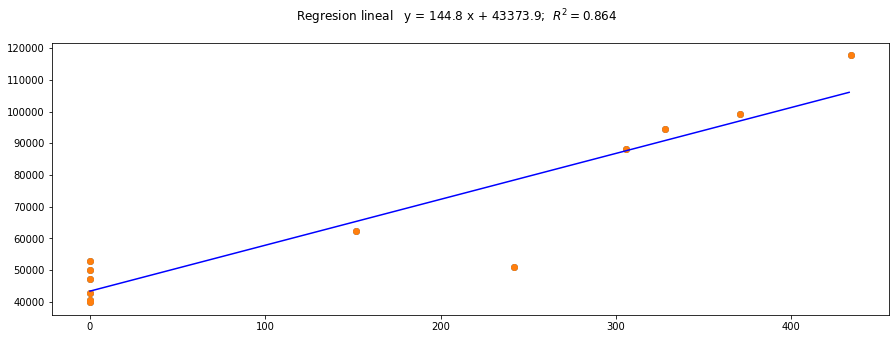

In [2]:
# Ejercicio caso real (II): cálculo de Baselines p63
# python trendline linear regression coefficient of determination
# https://en.wikipedia.org/wiki/Linear_regression
# ///////////////////////////////////////////////
#  definir en las tablas las variables
import numpy as np
import pandas as pd
import datetime

pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import base64
from io import BytesIO


# ls datos/efe*.*
df=pd.DataFrame()


df=pd.read_csv("datos/datos.csv", index_col=0, header=0)
y=df.kWh
x=df.Gradosdia
# Polynomial Regression
def polyfit(x, y, degree):
    results = {}

    coeffs = np.polyfit(x, y, degree)

     # Polynomial Coefficients
    results['polynomial'] = coeffs.tolist()

    # r-squared
    p = np.poly1d(coeffs)
    # fit values, and mean
    yhat = p(x)                         # or [p(z) for z in x]
    ybar = np.sum(y)/len(y)          # or sum(y)/len(y)
    ssreg = np.sum((yhat-ybar)**2)   # or sum([ (yihat - ybar)**2 for yihat in yhat])
    sstot = np.sum((y - ybar)**2)    # or sum([ (yi - ybar)**2 for yi in y])
    results['determination'] = ssreg / sstot

    return results
degree=1
model=np.polyfit(x, y, degree)
predict = np.poly1d(model)
model1= polyfit(x, y, degree)
m=round(model1['polynomial'][0],1)
b=round(model1['polynomial'][1],1)
R2=round(model1['determination'],3)


tt='Regresion lineal   y = '+str(m)+' x + '+str(b)+';  $R^2=$'+str(R2)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.scatter(x,y)
ax = plt.suptitle(tt)
# ax = plt.ylabel("kwh")
x_lin_reg = range(0, x.max())
y_lin_reg = predict(x_lin_reg)
ax = plt.scatter(x, y)
ax = plt.plot(x_lin_reg, y_lin_reg, c = 'b')

img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfa_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
# plt.close()

In [3]:
df

,Hasta,kg,kWh,Gradosdia
De,,,,
25/12/2010,17/01/2011,9290,117707,434
18/01/2011,14/02/2011,7456,94464,328
15/02/2011,14/03/2011,6955,88114,306
15/03/2011,18/04/2011,4923,62369,152
19/04/2011,16/05/2011,4179,52943,0
17/05/2011,20/06/2011,3715,47073,0
21/06/2011,18/07/2011,3378,42793,0
19/07/2011,24/08/2011,3195,40477,0
25/08/2011,19/09/2011,3142,39804,0
